# **🎬 Movie Rating Prediction Using Machine Learning**

**Project Type:**
Data Science Internship Project

**Dataset:**
IMDb India Movies Dataset

**Author:**
Avi Patel

---

# Problem Statement

This project aims to predict movie ratings using machine learning techniques based on movie features such as genre, director, duration, votes, and year. By analyzing historical movie data, the model identifies patterns that influence ratings and predicts future movie ratings accurately.

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

# **Upload Dataset**

In [2]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(
    list(uploaded.keys())[0],
    encoding='latin1'
)

Saving IMDb Movies India.csv to IMDb Movies India.csv


# **Dataset Overview**

In [3]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [4]:
df.shape

(15509, 10)

In [5]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


# **Missing Values**

In [8]:
df.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


# **Data Cleaning**

In [9]:
df = df.dropna(
    subset=['Rating']
)

In [10]:
df['Genre'] = df['Genre'].fillna('Unknown')

df['Director'] = df['Director'].fillna('Unknown')

df['Actor 1'] = df['Actor 1'].fillna('Unknown')

# **Statistical Summary**

In [11]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


# **Rating Distribution**

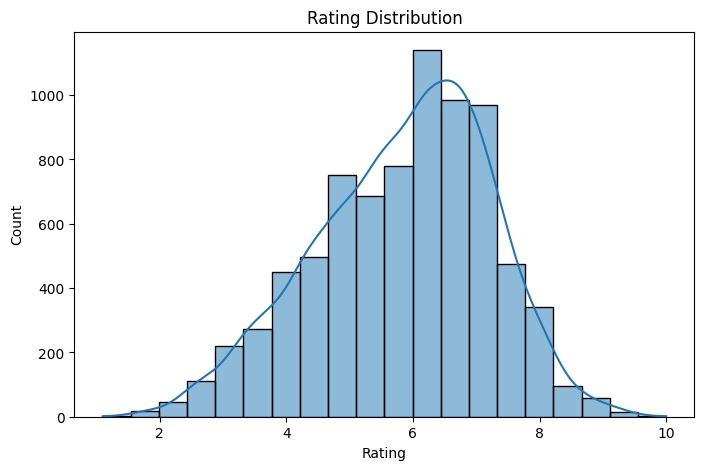

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Rating'],
    bins=20,
    kde=True
)

plt.title("Rating Distribution")

plt.show()

# **Top 10 Genres**

In [13]:
top_genres = df['Genre'].value_counts().head(10)

top_genres

,count
Genre,
Drama,1177
"Drama, Romance",447
"Action, Crime, Drama",417
Action,417
"Drama, Family",291
"Action, Drama",271
Comedy,259
"Comedy, Drama",239
Romance,234


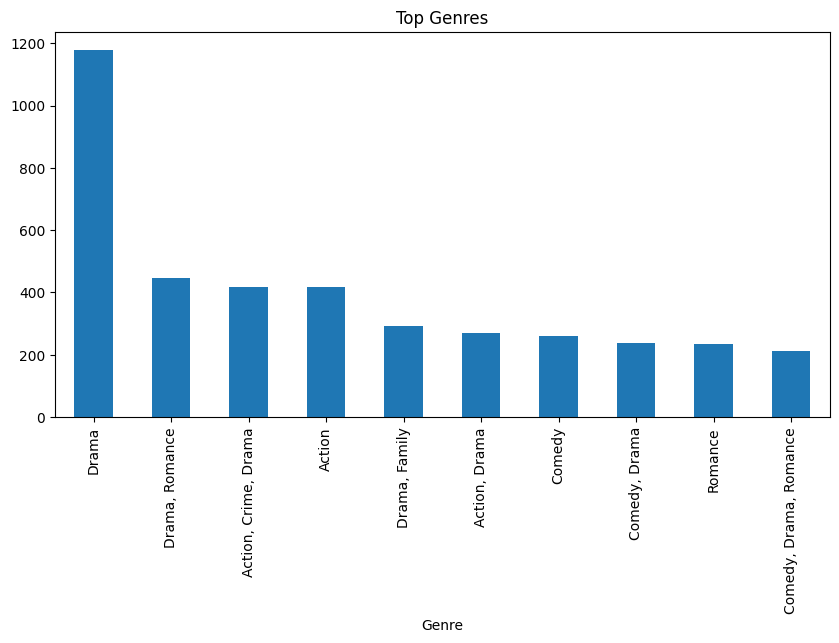

In [14]:
plt.figure(figsize=(10,5))

top_genres.plot(kind='bar')

plt.title("Top Genres")

plt.show()

# **Top 10 Directors**

In [15]:
top_directors = df['Director'].value_counts().head(10)

top_directors

,count
Director,
Mahesh Bhatt,47
David Dhawan,43
Hrishikesh Mukherjee,42
Shakti Samanta,39
Kanti Shah,38
Rama Rao Tatineni,34
Ram Gopal Varma,34
Basu Chatterjee,34
Vikram Bhatt,33


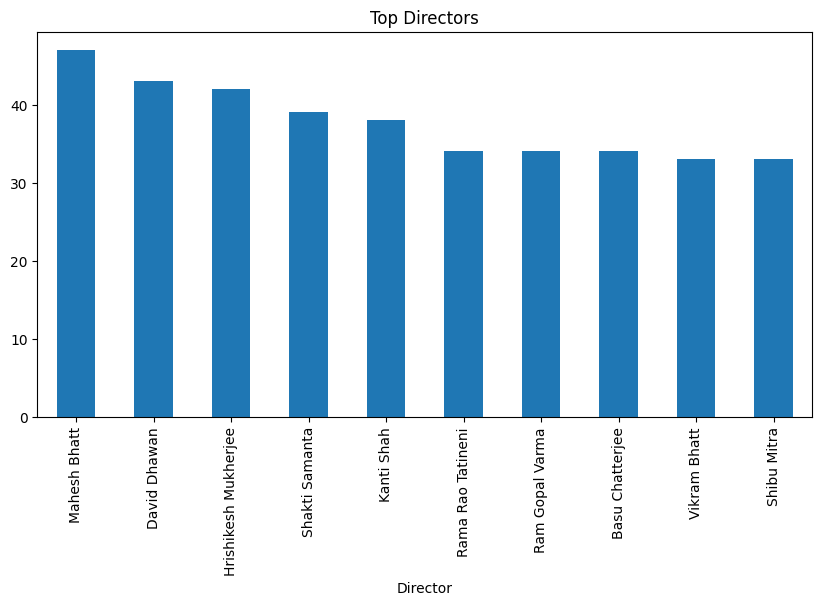

In [16]:
plt.figure(figsize=(10,5))

top_directors.plot(kind='bar')

plt.title("Top Directors")

plt.show()

# **Top 10 Highest Rated Movies**

In [17]:
top_movies = df[
    ['Name','Rating']
].sort_values(
    by='Rating',
    ascending=False
).head(10)

top_movies

,Name,Rating
8339,Love Qubool Hai,10.0
5410,Half Songs,9.7
2563,Breed,9.6
5077,Gho Gho Rani,9.4
14222,The Reluctant Crime,9.4
6852,June,9.4
11704,Ram-Path,9.4
9105,Meher,9.3
5125,God of gods,9.3
11843,Refl3ct,9.3


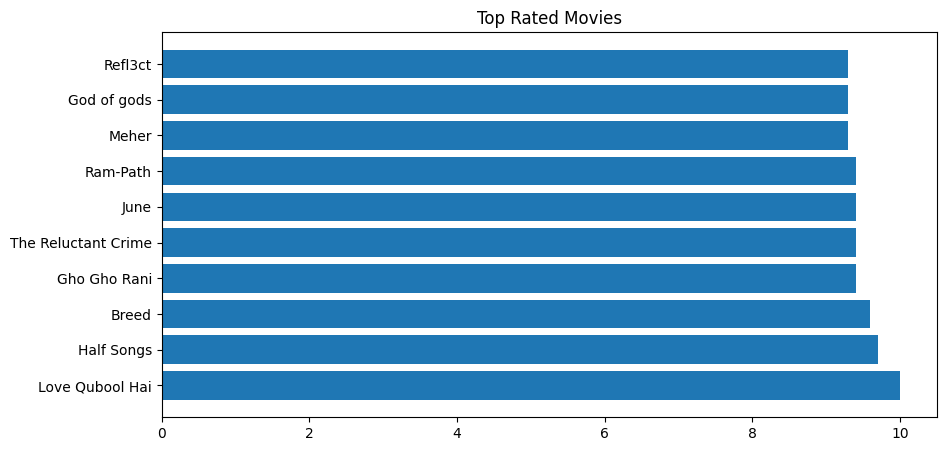

In [18]:
plt.figure(figsize=(10,5))

plt.barh(
    top_movies['Name'],
    top_movies['Rating']
)

plt.title(
    "Top Rated Movies"
)

plt.show()

# **Rating vs Votes**

In [19]:
df['Votes'] = df['Votes'].astype(str)

df['Votes'] = df['Votes'].str.replace(
    ',',
    ''
)

df['Votes'] = pd.to_numeric(
    df['Votes'],
    errors='coerce'
)

df['Votes'] = df['Votes'].fillna(0)

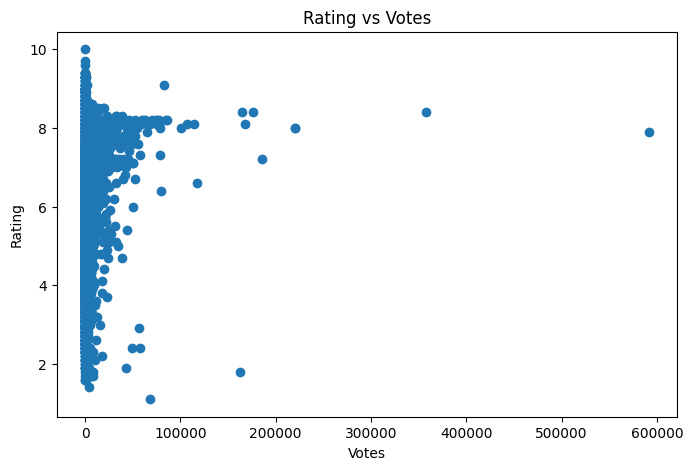

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Votes'],
    df['Rating']
)

plt.xlabel("Votes")

plt.ylabel("Rating")

plt.title(
    "Rating vs Votes"
)

plt.show()

# **Correlation Heatmap**

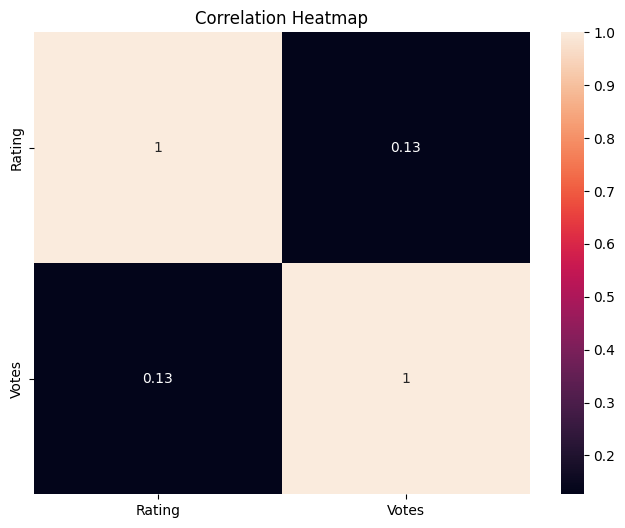

In [21]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

# **Label Encoding**

In [22]:
encoder = LabelEncoder()

df['Genre'] = encoder.fit_transform(
    df['Genre']
)

df['Director'] = encoder.fit_transform(
    df['Director']
)

df['Actor 1'] = encoder.fit_transform(
    df['Actor 1']
)

# **Feature Selection**

In [23]:
features = [
    'Genre',
    'Director',
    'Actor 1',
    'Votes'
]

X = df[features]

y = df['Rating']

# **Train Test Split**

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Train Model**

In [25]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

# **Prediction**

In [26]:
y_pred = model.predict(
    X_test
)

# **MAE**

In [27]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 0.9650663720538721


# **RMSE**

In [28]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("RMSE:", rmse)

RMSE: 1.2295501788085728


# **R² Score**

In [29]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R2 Score:", r2)

R2 Score: 0.18683398667534667


# **Actual vs Predicted Graph**

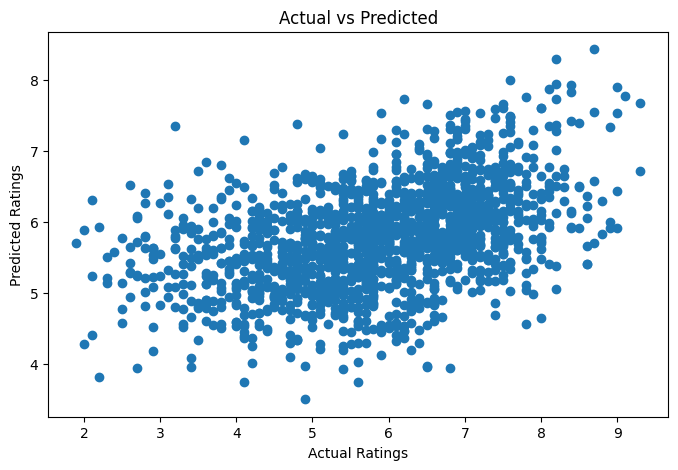

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel(
    "Actual Ratings"
)

plt.ylabel(
    "Predicted Ratings"
)

plt.title(
    "Actual vs Predicted"
)

plt.show()

# **Feature Importance**

In [31]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance

,Feature,Importance
0,Genre,0.224913
1,Director,0.244130
2,Actor 1,0.253080
3,Votes,0.277876


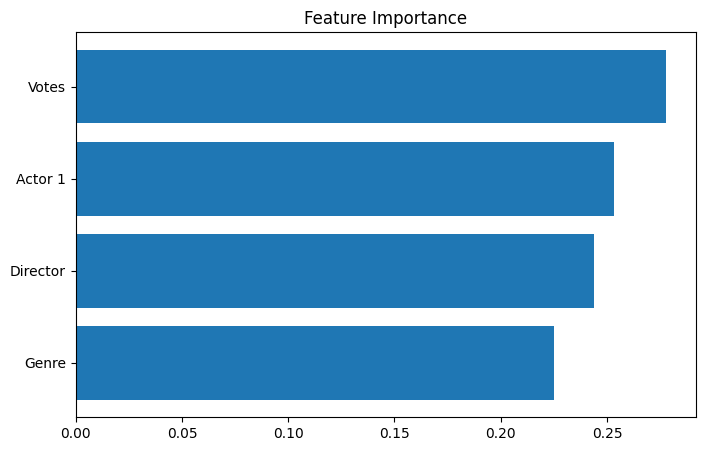

In [32]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title(
    "Feature Importance"
)

plt.show()

# **Sample Prediction**

In [33]:
sample = pd.DataFrame({
    'Genre':[1],
    'Director':[10],
    'Actor 1':[15],
    'Votes':[5000]
})

prediction = model.predict(
    sample
)

print(
    "Predicted Rating:",
    round(
        prediction[0],
        2
    )
)

Predicted Rating: 4.65


# 💼 Business Insights

- Movies with higher votes generally receive better ratings.
- Director reputation strongly influences ratings.
- Genre affects audience preferences.
- Popular actors contribute to higher-rated movies.

# 🚀 Future Scope

- Include Actor 2 and Actor 3.
- Use XGBoost.
- Hyperparameter Tuning.
- Deploy using Streamlit.
- Build a Movie Rating Prediction Web App.

# 📝 Conclusion

A machine learning model was successfully developed to predict movie ratings using IMDb India movie data. The project involved data cleaning, exploratory data analysis, feature engineering, model building, and evaluation. The results demonstrate how machine learning can be applied to estimate movie ratings and analyze the factors that influence audience preferences.